# 01 Quick start: an MITgcm verification experiment in mitjax

- **Tier:** laptop (CPU only)
- **Run time:** about 2 min (measured: 118 s on a compute node pinned to 8 cores; most of it is compiling)
- **Peak memory:** about 2 GB (measured: 2.0 GiB)
- **Experiment:** `verification/tutorial_barotropic_gyre`, variant `input` (62 x 62 x 1, 10 time steps)
- **Shows:** load an experiment, run it, compare the output with the Fortran's `results/output.txt` as
  `testreport` does, plot the sea-surface height and the velocity; the same from the command line.

mitjax reads the experiment exactly as MITgcm does: the `code/` directory (`SIZE.h`, the CPP options,
`packages.conf`) and the input directory (`data`, `data.pkg`, `eedata`, the binary input files). It needs one thing
from you: an MITgcm checkout at commit `63cdc0b` in the environment variable `MJX_UPSTREAM`. Nothing is compiled
with a Fortran compiler; the C preprocessor (`cpp`) is used on the options files, as `genmake2` does.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")      # the laptop notebooks run on the CPU

import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mitjax
from mitjax import paths

VERIFICATION = paths.UPSTREAM / "verification"     # $MJX_UPSTREAM/verification
print("MITgcm checkout found:", (VERIFICATION / "tutorial_barotropic_gyre").is_dir())


def new_out(name):
    """A new output directory runs/<name>-<n> next to this notebook (mitjax never writes into an existing one)."""
    n = 1
    while Path(f"runs/{name}-{n}").exists():
        n += 1
    return Path(f"runs/{name}-{n}")

MITgcm checkout found: True


## Load the experiment

`mitjax.load` takes the experiment directory and the input variant (`input`, `input.<x>`, `input_ad`, ...). It
reads the namelists and runs `cpp` on the CPP options of `code/`. Nothing is computed yet.

In [2]:
exp = mitjax.load(VERIFICATION / "tutorial_barotropic_gyre", variant="input")
cfg = exp.config.cfg
static = {k[2]: v for k, v in cfg.static}
print("grid:", cfg.size.Nx, "x", cfg.size.Ny, "x", cfg.size.Nr, " tiles:", cfg.size.nSx * cfg.size.nSy)
print("nTimeSteps =", static["ntimesteps"], " deltaT =", float(exp.config.params["data:parm03:deltat"]), "s")
print("packages compiled:", ", ".join(cfg.packages))

grid: 62 x 62 x 1  tiles: 1
nTimeSteps = 10  deltaT = 1200.0 s
packages compiled: debug, generic_advdiff, mdsio, mom_common, mom_fluxform, mom_vecinv, monitor, rw


## Run it

`exp.run(out=...)` makes a run directory `<out>/rundir` with the input files linked (as `testreport` links them),
runs the time steps and writes `output.txt` there: the `cg2d` solver lines and the `%MON` monitor blocks in the
Fortran's format. The first run in a session spends most of its time compiling the time step (XLA); the steps
themselves take a fraction of a second here.

In [3]:
out = new_out("01_gyre")
t0 = time.time()
run = exp.run(out=out)
print(f"ran in {time.time() - t0:.0f} s; output: {os.path.relpath(run.output)}")
lines = run.output.read_text().splitlines()
mon = [ln for ln in lines if "%MON time_secondsf" in ln or "%MON dynstat_eta_max" in ln]
print("\n".join(mon[-2:]))                         # the last monitor record: time and the maximum of etaN

ran in 85 s; output: runs/01_gyre-1/rundir/output.txt
(PID.TID 0000.0001) %MON time_secondsf                =   1.2000000000000E+04
(PID.TID 0000.0001) %MON dynstat_eta_max              =   4.5676733862490E-04


## Compare with the Fortran

`mitjax.compare` is MITgcm's `testreport` comparison (the same check list, the same digit count of the
monitor and solver values, the same pass criterion of 10 digits), here against
`tutorial_barotropic_gyre/results/output.txt`, which the Fortran wrote. On our Linux reference machine the two
agree to every printed digit (testreport reports 16); another CPU or compiler may round differently in the last
bits, so this notebook asserts testreport's own pass criterion.

In [4]:
rep = mitjax.compare(run, exp.results())
print(rep.summary)
for v in rep.run.variables:
    print(f"  {v.name:12s} {v.digits:3d} digits")

MIN_DIGITS = 10                                    # testreport's MATCH_CRIT
assert rep.verdict == "pass", rep.summary
assert min(v.digits for v in rep.run.variables) >= MIN_DIGITS

Y Y Y Y>16<16 16 16 22 16 16 16 22 16 16 16 16 16 16 16 16  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . pass  tutorial_barotropic_gyre
  PS            16 digits
  Tmn           16 digits
  Tmx           16 digits
  Tav           16 digits
  Tsd           22 digits
  Smn           16 digits
  Smx           16 digits
  Sav           16 digits
  Ssd           22 digits
  Umn           16 digits
  Umx           16 digits
  Uav           16 digits
  Usd           16 digits
  Vmn           16 digits
  Vmx           16 digits
  Vav           16 digits
  Vsd           16 digits


## Look at the result

`run.fields` holds the final model state by its Fortran names (`etaN`, `uVel`, `vVel`, ...) as numpy arrays in
mitjax's storage layout `[tile, k, j, i]` with halos; `run.interior(name)` drops the halos. The grid spacing is
read from the namelist (`delX`, `delY` in `data`, PARM04).

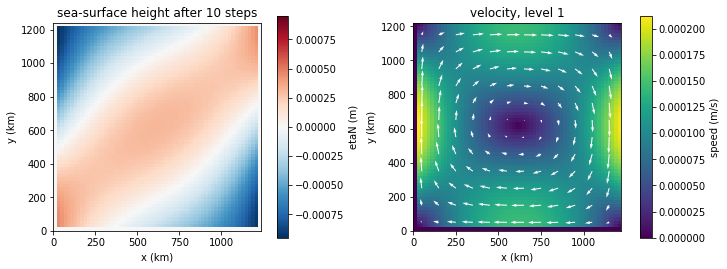

In [5]:
eta = run.interior("etaN")[0]                      # [j, i] of the one tile
u, v = run.interior("uVel")[0, 0], run.interior("vVel")[0, 0]    # level k = 1
dx = float(exp.config.params["data:parm04:delx(1)"]) / 1e3        # km
x = (np.arange(cfg.size.Nx) + 0.5) * dx
y = (np.arange(cfg.size.Ny) + 0.5) * dx
uc = 0.5 * (u[:-1, :-1] + u[:-1, 1:])              # u is on the western face: average to the centres
vc = 0.5 * (v[:-1, :-1] + v[1:, :-1])              # v is on the southern face
xc, yc = x[:-1], y[:-1]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8), dpi=72, constrained_layout=True)
pc = ax[0].pcolormesh(x, y, eta, cmap="RdBu_r", vmin=-abs(eta).max(), vmax=abs(eta).max())
fig.colorbar(pc, ax=ax[0], label="etaN (m)")
ax[0].set_title(f"sea-surface height after {static['ntimesteps']} steps")
sp = ax[1].pcolormesh(xc, yc, np.hypot(uc, vc), cmap="viridis")
fig.colorbar(sp, ax=ax[1], label="speed (m/s)")
s = slice(2, None, 5)
ax[1].quiver(xc[s], yc[s], uc[s, s], vc[s, s], color="w")
ax[1].set_title("velocity, level 1")
for a in ax:
    a.set_xlabel("x (km)"); a.set_ylabel("y (km)"); a.set_aspect("equal")
plt.show()
assert np.isfinite(eta).all() and np.abs(eta).max() > 0

## The same from the command line

The API has a command-line mirror. The run above is

```
python -m mitjax run $MJX_UPSTREAM/verification/tutorial_barotropic_gyre --variant input --out runs/gyre
```

and `python -m mitjax compare` does the comparison; its exit code is testreport's verdict (0 pass, 1 FAIL).
Here we run only the comparison, on the output the API run wrote:

In [6]:
import subprocess
import sys

cli = subprocess.run([sys.executable, "-m", "mitjax", "compare", str(os.path.relpath(run.output)),
                      str(VERIFICATION / "tutorial_barotropic_gyre"), "--variant", "input"],
                     capture_output=True, text=True)
print(cli.stdout)
assert cli.returncode == 0, cli.stderr[-500:]

  PS        16
  Tmn       16
  Tmx       16
  Tav       16
  Tsd       22
  Smn       16
  Smx       16
  Sav       16
  Ssd       22
  Umn       16
  Umx       16
  Uav       16
  Usd       16
  Vmn       16
  Vmx       16
  Vav       16
  Vsd       16
Y Y Y Y>16<16 16 16 22 16 16 16 22 16 16 16 16 16 16 16 16  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . pass  tutorial_barotropic_gyre



## Next

- [02_fortran_to_jax](02_fortran_to_jax.ipynb): read a routine next to its `.F`, change it, and see what
  `testreport` says.
- [03_first_gradient](03_first_gradient.ipynb): an adjoint gradient compared with TAF's.
- [04_own_configuration](04_own_configuration.ipynb): your own experiment, outside the MITgcm tree.